In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [9]:
cifar=keras.datasets.cifar10
(x_train,y_train),(x_test,y_test)=cifar.load_data()
x_train,x_test=x_train/255.0,x_test/255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 417s 2us/step


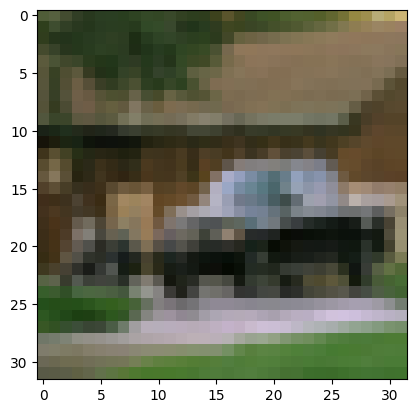

In [13]:
import matplotlib.pyplot as plt
plt.imshow(x_train[599])

In [11]:
model=keras.models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,810 (737.54 KB)

 Trainable params: 188,810 (737.54 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.add(layers.Flatten(input_shape=(32,32,3)))
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,810 (737.54 KB)

 Trainable params: 188,810 (737.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
data=model.fit(x_train,y_train,validation_split=0.1,epochs=15)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 48ms/step - accuracy: 0.4410 - loss: 1.5313 - val_accuracy: 0.5568 - val_loss: 1.2251
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 45ms/step - accuracy: 0.5817 - loss: 1.1771 - val_accuracy: 0.6108 - val_loss: 1.0988
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.6453 - loss: 1.0002 - val_accuracy: 0.6684 - val_loss: 0.9423
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.6869 - loss: 0.8898 - val_accuracy: 0.7010 - val_loss: 0.8507
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.7154 - loss: 0.8089 - val_accuracy: 0.7022 - val_loss: 0.8478
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 45ms/step - accuracy: 0.7379 - loss: 0.7426 - val_accuracy: 0.6936 - val_loss: 0.8924
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.7637 - loss: 0.6794 - val_accuracy: 0.7212 - val_loss: 0.8004
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.7784 -

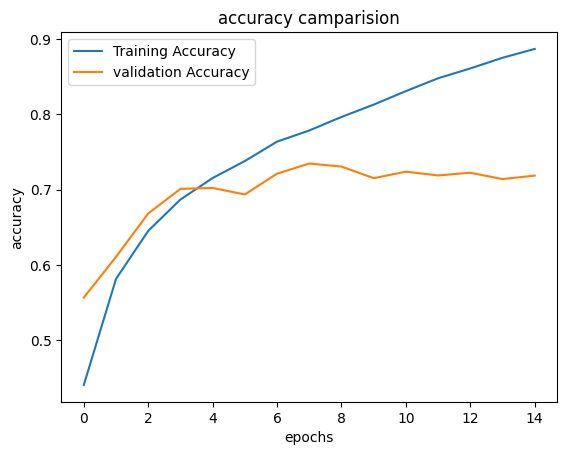

In [25]:
plt.plot(data.history['accuracy'],label='Training Accuracy')
plt.plot(data.history['val_accuracy'],label='validation Accuracy')
plt.title("accuracy camparision")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()

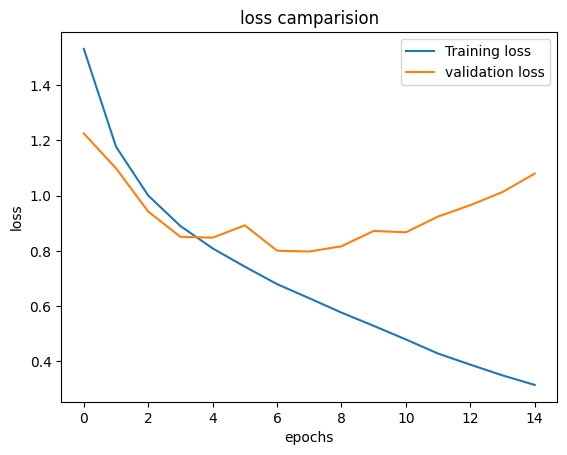

In [27]:
plt.plot(data.history['loss'],label='Training loss')
plt.plot(data.history['val_loss'],label='validation loss')
plt.title("loss camparision")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()

In [53]:
import tensorflow as tf
from tensorflow.keras.layers import Input,LSTM,Dense
from tensorflow.keras import Model


In [54]:
mnist=keras.datasets.mnist
(train_images,train_labels),(test_images,test_labels)=mnist.load_data()
train_images,test_images=train_images/255.0,test_images/255.0

In [55]:
input_shape=(28,28)
inputs=Input(shape=input_shape)
rnn_layer=LSTM(128)(inputs)
outputs=Dense(10,activation='softmax')(rnn_layer)
model=Model(inputs=inputs,outputs=outputs)

In [56]:
import numpy as np

train_images = np.array(train_images, dtype=np.float32)
train_labels = np.array(train_labels, dtype=np.int32)

print("Images shape:", train_images.shape)
print("Labels shape:", train_labels.shape)


Images shape: (60000, 28, 28)
Labels shape: (60000,)


In [57]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
data = model.fit(train_images, train_labels, validation_split=0.1, epochs=10)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 66s 38ms/step - accuracy: 0.8782 - loss: 0.3743 - val_accuracy: 0.9677 - val_loss: 0.1111
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.9661 - loss: 0.1133 - val_accuracy: 0.9793 - val_loss: 0.0713
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.9765 - loss: 0.0773 - val_accuracy: 0.9818 - val_loss: 0.0664
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.9823 - loss: 0.0595 - val_accuracy: 0.9827 - val_loss: 0.0569
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.9843 - loss: 0.0481 - val_accuracy: 0.9817 - val_loss: 0.0644
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 80s 38ms/step - accuracy: 0.9876 - loss: 0.0412 - val_accuracy: 0.9888 - val_loss: 0.0417
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.9889 - loss: 0.0358 - val_accuracy: 0.9873 - val_loss: 0.0489
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 39ms/step - accuracy: 0.9907 -